# AI LÀ AI

Notebook baseline tạo trực tiếp `submission.zip` cho tập kiểm tra.

## 1. Cấu hình

In [1]:
!unzip -P 629436 -q /kaggle/input/datasets/phnguyencs/qa-dataset/TACVU1/data/private_test.zip

In [147]:
import os

# Phải đặt trước khi torch khởi tạo CUDA.
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

from pathlib import Path
import random
import time
import zipfile
from torchvision import models
import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageOps
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import v2

TRAIN_ROOT = Path('/kaggle/input/datasets/phnguyencs/qa-dataset/TACVU1/data')
TEST_ROOT = Path('/kaggle/working/private_test')

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Cố định kết quả giữa các lần chạy: cùng seed -> cùng file nộp.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[cấu hình] thiết bị: {DEVICE}'
      + (f' ({torch.cuda.get_device_name(0)})' if DEVICE.type == 'cuda' else ''))

[cấu hình] thiết bị: cuda (Tesla T4)


## 2. Mô hình và phép biến đổi ảnh

In [148]:
backbone = models.resnet18(weights='DEFAULT')


In [149]:
dim = backbone.fc.in_features
print(dim)

512


In [150]:
backbone.fc = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(dim, 2)
)

In [151]:
feature_modules = nn.Sequential(*list(backbone.children())[:-1])
head_module = list(backbone.children())[-1]
print(len(feature_modules), len(head_module))
param_groups = [
    {
        'params': feature_modules.parameters(),
        'lr': 1e-4,        
        'weight_decay': 1e-2
    },
    {
        'params': head_module.parameters(),
        'lr': 1e-3,       
        'weight_decay': 1e-2
    }
]

9 2


In [152]:
total_params = sum(p.numel() for p in backbone.parameters())
print(total_params)

11177538


In [ ]:
train_tf = v2.Compose([
    v2.ToImage(),
    v2.Resize(256),
    v2.RandomResizedCrop((224, 224), scale=(0.75, 1.0)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomApply([v2.ColorJitter(0.2, 0.2, 0.2, 0.05)], p=0.8),
    v2.RandomGrayscale(p=0.05),
    v2.ToDtype(torch.float, scale=True),
    v2.Normalize((.485, .456, .406), (.229, .224, .225))
])
test_tf = v2.Compose([
    v2.ToImage(),
    v2.Resize(256),
    v2.CenterCrop((224, 224)),
    v2.ToDtype(torch.float, scale=True),
    v2.Normalize((.485, .456, .406), (.229, .224, .225))
])

## 3. Dataset

In [154]:
def load_image(path: Path, tf):
    with Image.open(path) as image:
        return tf(ImageOps.exif_transpose(image).convert('RGB'))


class FaceImages(Dataset):
    """Đọc ảnh khuôn mặt; có nhãn khi huấn luyện, trả tên file khi dự đoán."""

    def __init__(self, rows, root, tf, labeled=True):
        self.rows = rows.reset_index(drop=True)
        self.root = root
        self.tf = tf
        self.labeled = labeled

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows.iloc[index]
        name = Path(row.path).name if self.labeled else row.file_name
        image = load_image(self.root / 'images' / name, self.tf)
        return (image, int(row.label)) if self.labeled else (image, name)


print('[dataset] đã định nghĩa FaceImages (dùng chung cho train và dự đoán)')

[dataset] đã định nghĩa FaceImages (dùng chung cho train và dự đoán)


## 4. Nạp dữ liệu

In [ ]:
from sklearn.model_selection import train_test_split

df = pd.read_csv(TRAIN_ROOT / 'train' / 'manifest.csv')
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df['label']
)

train_data = FaceImages(train_df, TRAIN_ROOT / 'train', train_tf)
val_data = FaceImages(val_df, TRAIN_ROOT / 'train', test_tf)
query = pd.DataFrame({
    'file_name': sorted(p.name for p in (TEST_ROOT / 'images').iterdir() if p.is_file())
})
BATCH_SIZE = 64
LOADER_KWARGS = {
    'batch_size': BATCH_SIZE,
    'pin_memory': DEVICE.type == 'cuda',
    'num_workers': 2,
    'persistent_workers': True,
}
train_loader = DataLoader(train_data, shuffle=True, **LOADER_KWARGS)
val_loader = DataLoader(val_data, shuffle=False, **LOADER_KWARGS)
print(f'[dữ liệu] train: {len(train_data):,} ảnh')
print(f'[dữ liệu] val: {len(val_data):,} ảnh')
print(f'[dữ liệu] Test: {len(query):,} ảnh cần dự đoán')
print(f'[dữ liệu] phân bố nhãn train: {train_df.label.value_counts().to_dict()}')

[dữ liệu] train: 1,600 ảnh
[dữ liệu] val: 400 ảnh
[dữ liệu] Test: 200 ảnh cần dự đoán
[dữ liệu] phân bố nhãn train: {0: 803, 1: 797}


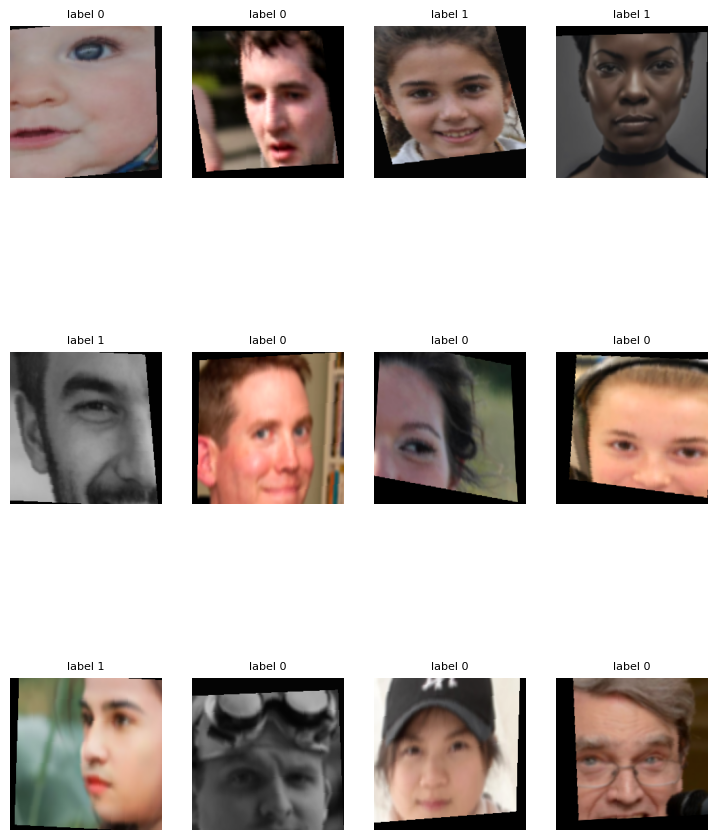

In [156]:
import matplotlib.pyplot as plt
imgs, labels = next(iter(train_loader))
fig, ax = plt.subplots(3, 4, figsize= (9, 12))
ax = ax.flatten()
mean = torch.tensor([0.485, 0.456, 0.406]).reshape(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).reshape(3, 1, 1)

for i in range(12):
    img, label = imgs[i], labels[i]
    img = img * std + mean
    img = img.permute(1,2,0).numpy()
    ax[i].imshow(img)
    ax[i].set_title(f"label {label}", fontsize=8)
    ax[i].axis('off')
plt.show()

In [157]:
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support

## 5. Huấn luyện

In [ ]:
backbone = backbone.to(DEVICE)
optimizer = torch.optim.AdamW(
    [
        {'params': feature_modules.parameters(), 'lr': 3e-5},
        {'params': head_module.parameters(), 'lr': 3e-4},
    ],
    betas=(0.9, 0.999),
    weight_decay=1e-4,
)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
best_f1 = -1.0
best_model_path = './best_model.pth'

In [ ]:
from torch.nn.utils import clip_grad_norm_

def soft_cross_entropy(logits, target_a, target_b, mix):
    return mix * criterion(logits, target_a) + (1.0 - mix) * criterion(logits, target_b)


def train_epoch(epoch, epochs, train_loader, scheduler):
    backbone.train()
    correct, count = 0, 0
    losses = []
    progress = tqdm(train_loader, desc=f'Train {epoch}/{epochs}')
    for images, labels in progress:
        images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        # MixUp/CutMix regularize only some batches; clean batches preserve the original labels.
        use_mix = random.random() < 0.5
        if use_mix:
            permutation = torch.randperm(images.size(0), device=DEVICE)
            mixed_labels = labels[permutation]
            mix = np.random.beta(0.4, 0.4)
            if random.random() < 0.5:
                images = mix * images + (1.0 - mix) * images[permutation]
            else:
                height, width = images.shape[-2:]
                cut_ratio = np.sqrt(1.0 - mix)
                cut_width, cut_height = int(width * cut_ratio), int(height * cut_ratio)
                center_x = random.randrange(width)
                center_y = random.randrange(height)
                x0 = max(center_x - cut_width // 2, 0)
                x1 = min(center_x + cut_width // 2, width)
                y0 = max(center_y - cut_height // 2, 0)
                y1 = min(center_y + cut_height // 2, height)
                images[:, :, y0:y1, x0:x1] = images[permutation, :, y0:y1, x0:x1]
                mix = 1.0 - ((x1 - x0) * (y1 - y0) / (width * height))
            outputs = backbone(images)
            loss = soft_cross_entropy(outputs, labels, mixed_labels, mix)
        else:
            outputs = backbone(images)
            loss = criterion(outputs, labels)

        loss.backward()
        clip_grad_norm_(backbone.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())
        pred = outputs.argmax(1)
        correct += (pred == labels).sum().item()
        count += labels.size(0)

    return correct / count, sum(losses) / len(losses)


def evaluate(epoch, epochs, val_loader):
    backbone.eval()
    correct, count = 0, 0
    losses = []
    preds, labels_all = [], []
    with torch.inference_mode():
        for images, labels in tqdm(val_loader, desc=f'Val {epoch}/{epochs}'):
            images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            outputs = backbone(images)
            losses.append(criterion(outputs, labels).item())
            pred = outputs.argmax(1)
            correct += (pred == labels).sum().item()
            count += labels.size(0)
            preds.extend(pred.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels_all, preds, average='macro', zero_division=0
    )
    return correct / count, sum(losses) / len(losses), precision, recall, f1

In [160]:
train_accs, train_losses, val_accs, val_losses, f1s = [],[],[],[],[] 

In [ ]:
def train_model(epochs, train_loader, val_loader, patience=8):
    global best_f1
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=[3e-5, 3e-4],
        total_steps=epochs * len(train_loader),
        pct_start=0.15,
        anneal_strategy='cos',
        div_factor=10,
        final_div_factor=100,
    )
    wait = 0
    for epoch in range(1, epochs + 1):
        train_acc, train_loss = train_epoch(epoch, epochs, train_loader, scheduler)
        val_acc, val_loss, precision, recall, f1 = evaluate(epoch, epochs, val_loader)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        f1s.append(f1)
        print(f'Train Acc: {train_acc:.4f}, Train loss: {train_loss:.4f}')
        print(f'Val Acc: {val_acc:.4f}, Val loss: {val_loss:.4f}')
        print(f'F1: {f1 * 100:.2f}% | Precision: {precision * 100:.2f}% | Recall: {recall * 100:.2f}%')

        if f1 > best_f1:
            best_f1 = f1
            torch.save(backbone.state_dict(), best_model_path)
            wait = 0
            print(f'Checkpoint at epoch {epoch}')
        else:
            wait += 1
            if wait >= patience:
                print(f'Early stopping at epoch {epoch}')
                break

In [162]:
# import torch
# import gc

# # 1. Xóa các biến/mô hình đang chiếm VRAM
# del backbone
# # del labels

# # 2. Gọi bộ gom rác của Python
# gc.collect()

# 3. Làm trống bộ nhớ đệm của PyTorch CUDA
# torch.cuda.empty_cache()


In [ ]:
train_accs, train_losses, val_accs, val_losses, f1s = [], [], [], [], []
train_model(35, train_loader, val_loader, patience=8)

Val 1/80: 100%|██████████| 4/4 [00:02<00:00,  1.70it/s]


Train Acc: 0.5175, Train loss: 0.7441186400560232
Val Acc: 0.515, Val loss: 0.6839167028665543
F1: 49.26247515430484% | Precision: 51.43096384461258% | Recall: 51.19651921682379%
Checkpoint at epoch 1


Val 2/80: 100%|██████████| 4/4 [00:02<00:00,  1.64it/s]


Train Acc: 0.546875, Train loss: 0.7137469007418706
Val Acc: 0.5775, Val loss: 0.6885554641485214
F1: 56.93581780538302% | Precision: 58.1027456027456% | Recall: 57.55670025755795%
Checkpoint at epoch 2


Val 3/80: 100%|██████████| 4/4 [00:02<00:00,  1.67it/s]


...

Train Acc: 0.959375, Train loss: 0.28261443972587585
Val Acc: 0.7925, Val loss: 0.4971909150481224
F1: 79.12461723225121% | Precision: 79.72766217870257% | Recall: 79.15155910079767%


Val 79/80: 100%|██████████| 4/4 [00:02<00:00,  1.58it/s]


Train Acc: 0.96625, Train loss: 0.27236005205374497
Val Acc: 0.7925, Val loss: 0.49776332825422287
F1: 79.15502508303459% | Precision: 79.58603896103897% | Recall: 79.16656247655722%


Val 80/80: 100%|██████████| 4/4 [00:02<00:00,  1.36it/s]

Train Acc: 0.95875, Train loss: 0.2842203699625455
Val Acc: 0.79, Val loss: 0.4966712221503258
F1: 78.91089854635837% | Precision: 79.30125915228902% | Recall: 78.920257057838%


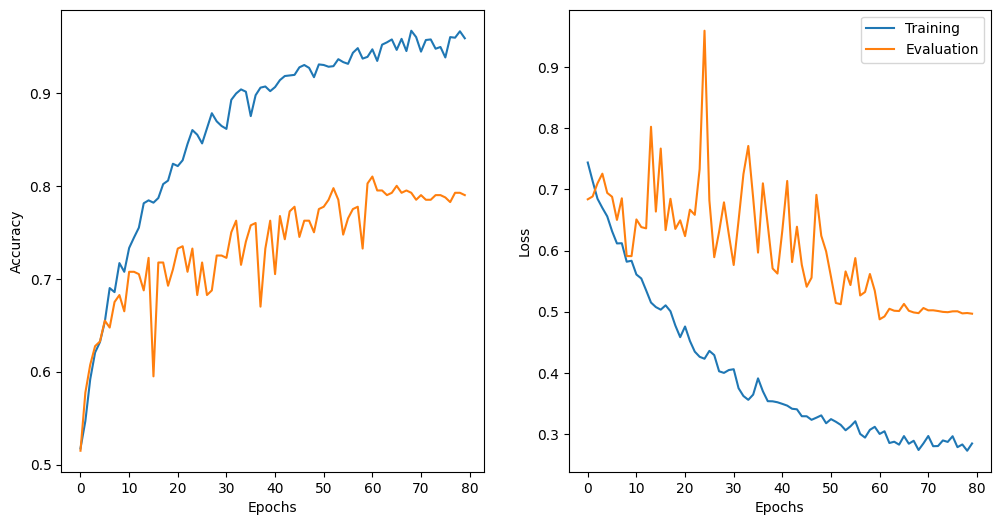

In [164]:
fig, axs = plt.subplots(nrows = 1, ncols =2 , figsize = (12,6))
epochs = list(range(len(train_accs)))
axs[0].plot(epochs,train_accs, label = "Training")
axs[0].plot(epochs, val_accs, label = "Evaluation")
axs[1].plot(epochs, train_losses, label = "Training")
axs[1].plot(epochs, val_losses, label = "Evaluation")
axs[0].set_xlabel("Epochs")
axs[1].set_xlabel("Epochs")
axs[0].set_ylabel("Accuracy")
axs[1].set_ylabel("Loss")
plt.legend()
plt.savefig('./training_curves.png')
plt.show()

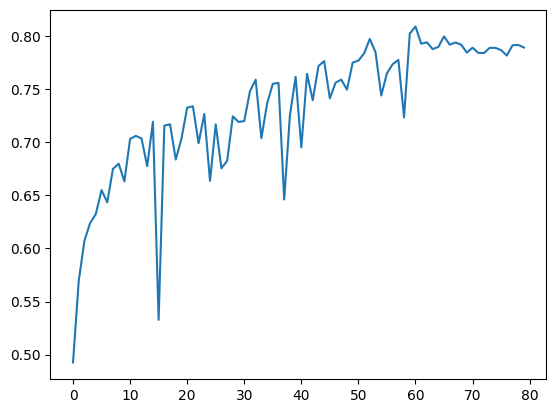

In [165]:
plt.plot(epochs, f1s)

## 6. Dự đoán và đóng gói bài nộp

In [ ]:
rows = []
started = time.time()
model = models.resnet18(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(dim, 2)
)
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=True))
model = model.to(DEVICE)
model.eval()
with torch.inference_mode():
    loader = DataLoader(
        FaceImages(query, TEST_ROOT, test_tf, labeled=False), batch_size=BATCH_SIZE,
        pin_memory=DEVICE.type == 'cuda',
    )
    for images, names in loader:
        labels = model(images.to(DEVICE, non_blocking=True)).argmax(1).cpu().tolist()
        rows.extend(zip(names, labels))

submission = pd.DataFrame(rows, columns=['file_name', 'category_id'])
submission.to_csv('submission.csv', index=False)

with zipfile.ZipFile('submission.zip', 'w', zipfile.ZIP_DEFLATED) as archive:
    archive.write('submission.csv')

print(f'[dự đoán] {len(submission):,} ảnh trong {time.time() - started:.1f}s')
print(f'[dự đoán] phân bố nhãn: {submission.category_id.value_counts().to_dict()}')
print('[nộp bài] đã tạo submission.zip (chứa đúng submission.csv ở thư mục gốc)')

[dự đoán] 200 ảnh trong 1.3s
[dự đoán] phân bố nhãn: {1: 107, 0: 93}
[nộp bài] đã tạo submission.zip (chứa đúng submission.csv ở thư mục gốc)
